In [ ]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_upi_transactions.csv to synthetic_upi_transactions.csv


In [ ]:
import pandas as pd
import numpy as np

transactions_df = pd.read_csv("synthetic_upi_transactions.csv")
transactions_df.shape

(80000, 20)

In [ ]:
transactions_df['timestamp'] = pd.to_datetime(transactions_df['timestamp'])
transactions_df['year_month'] = transactions_df['timestamp'].dt.to_period('M')

Monthly Income


In [ ]:
monthly_income = (
    transactions_df.groupby(['sender_upi_id','year_month'])['amount']
    .sum()
    .reset_index()
)

Income Stability

In [ ]:
income_stats = (
    monthly_income.groupby('sender_upi_id')['amount']
    .agg(['mean','std'])
    .reset_index()
)

income_stats['income_stability'] = income_stats['std'] / income_stats['mean']
income_stats['income_stability'].fillna(0, inplace=True)

/tmp/ipython-input-373/2131354695.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  income_stats['income_stability'].fillna(0, inplace=True)


Transaction Frequency

In [ ]:
txn_freq = (
    transactions_df.groupby('sender_upi_id')
    .size()
    .reset_index(name='txn_count')
)

txn_freq['txn_freq_norm'] = txn_freq['txn_count'] / 100

Network Centrality

In [ ]:
merchant_div = (
    transactions_df.groupby('sender_upi_id')['receiver_upi_id']
    .nunique()
    .reset_index(name='merchant_count')
)

merchant_div['network_centrality'] = merchant_div['merchant_count'] / 50

NSF Frequency

In [ ]:
nsf_df = transactions_df[transactions_df['transfer_ratio'] > 0.9]

nsf_freq = (
    nsf_df.groupby('sender_upi_id')
    .size()
    .reset_index(name='nsf_frequency')
)

Time-to-Zero

In [ ]:
ttz_df = transactions_df[transactions_df['transfer_ratio'] > 0.8]

ttz = (
    ttz_df.groupby('sender_upi_id')
    .size()
    .reset_index(name='near_zero_events')
)

ttz['time_to_zero_norm'] = 1 / (1 + ttz['near_zero_events'])

In [ ]:
borrowers_df = income_stats[['sender_upi_id','income_stability']]

borrowers_df = borrowers_df.merge(
    txn_freq[['sender_upi_id','txn_freq_norm']],
    on='sender_upi_id',
    how='left'
)

borrowers_df = borrowers_df.merge(
    merchant_div[['sender_upi_id','network_centrality']],
    on='sender_upi_id',
    how='left'
)

borrowers_df = borrowers_df.merge(
    nsf_freq,
    on='sender_upi_id',
    how='left'
)

borrowers_df = borrowers_df.merge(
    ttz[['sender_upi_id','time_to_zero_norm']],
    on='sender_upi_id',
    how='left'
)

borrowers_df.fillna(0, inplace=True)

borrowers_df.shape

(9866, 6)

In [ ]:
borrowers_df.head()

,sender_upi_id,income_stability,txn_freq_norm,network_centrality,nsf_frequency,time_to_zero_norm
0,aaronbautista@oksbi,0.523653,0.09,0.18,0.0,0.0
1,aaronbolton@oksbi,1.287587,0.09,0.18,0.0,0.0
2,aaronbrown@ybl,0.454635,0.08,0.16,0.0,0.0
3,aaronburton@okaxis,0.441269,0.07,0.14,0.0,0.0
4,aaroncarrillo@ybl,0.781350,0.11,0.22,0.0,0.0


In [ ]:
import numpy as np

np.random.seed(42)

# Debt to Income
borrowers_df['debt_to_income'] = np.random.uniform(0, 0.4, len(borrowers_df))

# Affordability Index (inverse of debt pressure)
borrowers_df['affordability_index'] = 1 - borrowers_df['debt_to_income']
borrowers_df['affordability_index'] *= np.random.uniform(0.7, 1.0, len(borrowers_df))
borrowers_df['affordability_index'] = borrowers_df['affordability_index'].clip(0,1)

# Bill Payment Latency
borrowers_df['bill_payment_latency'] = np.random.normal(3, 5, len(borrowers_df))
borrowers_df['bill_payment_latency'] = borrowers_df['bill_payment_latency'].clip(-10, 20)

In [ ]:
borrowers_df.shape

(9866, 9)

In [ ]:
borrowers_df.shape
borrowers_df.head()

,sender_upi_id,income_stability,txn_freq_norm,network_centrality,nsf_frequency,time_to_zero_norm,debt_to_income,affordability_index,bill_payment_latency
0,aaronbautista@oksbi,0.523653,0.09,0.18,0.0,0.0,0.149816,0.704247,-10.000000
1,aaronbolton@oksbi,1.287587,0.09,0.18,0.0,0.0,0.380286,0.470516,2.408958
2,aaronbrown@ybl,0.454635,0.08,0.16,0.0,0.0,0.292798,0.688277,2.964144
3,aaronburton@okaxis,0.441269,0.07,0.14,0.0,0.0,0.239463,0.572209,-9.412720
4,aaroncarrillo@ybl,0.781350,0.11,0.22,0.0,0.0,0.062407,0.736777,12.624192


In [ ]:
score = (
    2.0 * borrowers_df['income_stability']
    + 0.2 * borrowers_df['nsf_frequency']
    + 1.5 * borrowers_df['debt_to_income']
    + 0.05 * borrowers_df['bill_payment_latency']
    - 1.5 * borrowers_df['network_centrality']
    - 1.0 * borrowers_df['time_to_zero_norm']
    - 2.0 * borrowers_df['affordability_index']
)

score += np.random.normal(0, 0.8, len(borrowers_df))

prob = 1 / (1 + np.exp(-score))

threshold = np.percentile(prob, 70)

borrowers_df['default'] = (prob > threshold).astype(int)

In [ ]:
borrowers_df['default'].value_counts()
borrowers_df['default'].mean()

np.float64(0.3000202716399757)

In [ ]:
borrowers_df['default'].value_counts()
borrowers_df['default'].mean()
borrowers_df.describe()

,income_stability,txn_freq_norm,network_centrality,nsf_frequency,time_to_zero_norm,debt_to_income,affordability_index,bill_payment_latency,default
count,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.00000
mean,0.620760,0.081087,0.162145,0.058585,0.026150,0.197765,0.682752,2.997063,0.30002
std,0.259907,0.029983,0.059946,0.252737,0.108127,0.115020,0.120249,4.929024,0.45829
min,0.000000,0.010000,0.020000,0.000000,0.000000,0.000005,0.420946,-10.000000,0.00000
25%,0.432229,0.060000,0.120000,0.000000,0.000000,0.098647,0.591927,-0.406458,0.00000
50%,0.597787,0.080000,0.160000,0.000000,0.000000,0.197120,0.675292,3.012354,0.00000
75%,0.787278,0.100000,0.200000,0.000000,0.000000,0.296174,0.765824,6.365296,1.00000
max,1.766524,0.310000,0.620000,2.000000,0.500000,0.399887,0.998335,20.000000,1.00000


In [ ]:
borrowers_df.to_csv("borrower_behavior_dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("borrower_behavior_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

LightGBM model with monotonic constraints

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import numpy as np

feature_cols = [
    'income_stability',
    'affordability_index',
    'nsf_frequency',
    'bill_payment_latency',
    'network_centrality',
    'time_to_zero_norm',
    'debt_to_income',
    'txn_freq_norm'
]

X = borrowers_df[feature_cols]
y = borrowers_df['default']

monotonic_constraints = [1, -1, 1, 1, -1, -1, 1, -1]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        monotone_constraints=monotonic_constraints,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_pred)
    auc_scores.append(auc)

print("AUC scores:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))
print("Std AUC:", np.std(auc_scores))

[LightGBM] [Info] Number of positive: 2368, number of negative: 5524
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000714 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1077
[LightGBM] [Info] Number of data points in the train set: 7892, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300051 -> initscore=-0.847057
[LightGBM] [Info] Start training from score -0.847057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [ ]:
X.describe()

,income_stability,affordability_index,nsf_frequency,bill_payment_latency,network_centrality,time_to_zero_norm,debt_to_income,txn_freq_norm
count,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000,9866.000000
mean,0.620760,0.682752,0.058585,2.997063,0.162145,0.026150,0.197765,0.081087
std,0.259907,0.120249,0.252737,4.929024,0.059946,0.108127,0.115020,0.029983
min,0.000000,0.420946,0.000000,-10.000000,0.020000,0.000000,0.000005,0.010000
25%,0.432229,0.591927,0.000000,-0.406458,0.120000,0.000000,0.098647,0.060000
50%,0.597787,0.675292,0.000000,3.012354,0.160000,0.000000,0.197120,0.080000
75%,0.787278,0.765824,0.000000,6.365296,0.200000,0.000000,0.296174,0.100000
max,1.766524,0.998335,2.000000,20.000000,0.620000,0.500000,0.399887,0.310000


In [ ]:
y.value_counts(normalize=True)

,proportion
default,
0,0.69998
1,0.30002


In [ ]:
print(feature_cols)

['income_stability', 'affordability_index', 'nsf_frequency', 'bill_payment_latency', 'network_centrality', 'time_to_zero_norm', 'debt_to_income', 'txn_freq_norm']


Probability calibration

In [ ]:
from sklearn.model_selection import train_test_split

# 1️⃣ Split test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2️⃣ Split train + calibration
X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Calib:", X_calib.shape)
print("Test:", X_test.shape)

Train: (5919, 8)
Calib: (1973, 8)
Test: (1974, 8)


In [ ]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    monotone_constraints=[1, -1, 1, 1, -1, -1, 1, -1],
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1776, number of negative: 4143
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000400 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1072
[LightGBM] [Info] Number of data points in the train set: 5919, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300051 -> initscore=-0.847057
[LightGBM] [Info] Start training from score -0.847057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

LGBMClassifier(learning_rate=0.05, max_depth=6,
               monotone_constraints=[1, -1, 1, 1, -1, -1, 1, -1],
               n_estimators=300, random_state=42)

In [ ]:
from sklearn.metrics import brier_score_loss

raw_probs = model.predict_proba(X_test)[:, 1]

raw_brier = brier_score_loss(y_test, raw_probs)

print("Raw Brier Score:", raw_brier)

Raw Brier Score: 0.15635114564592803


In [ ]:
from sklearn.isotonic import IsotonicRegression

calibrator = IsotonicRegression(out_of_bounds='clip')

calibrator.fit(
    model.predict_proba(X_calib)[:, 1],
    y_calib
)

IsotonicRegression(out_of_bounds='clip')

In [ ]:
calibrated_probs = calibrator.transform(raw_probs)

calibrated_brier = brier_score_loss(y_test, calibrated_probs)

print("Calibrated Brier Score:", calibrated_brier)

Calibrated Brier Score: 0.15765224562854505


Explainability Engine

In [ ]:
# Combine train + calibration for final production model
X_dev = pd.concat([X_train, X_calib])
y_dev = pd.concat([y_train, y_calib])

model_final = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    monotone_constraints=[1, -1, 1, 1, -1, -1, 1, -1],
    random_state=42
)

model_final.fit(X_dev, y_dev)

[LightGBM] [Info] Number of positive: 2368, number of negative: 5524
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001648 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1075
[LightGBM] [Info] Number of data points in the train set: 7892, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300051 -> initscore=-0.847057
[LightGBM] [Info] Start training from score -0.847057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

LGBMClassifier(learning_rate=0.05, max_depth=6,
               monotone_constraints=[1, -1, 1, 1, -1, -1, 1, -1],
               n_estimators=300, random_state=42)

In [ ]:
import shap

explainer = shap.TreeExplainer(model_final)

In [ ]:
# pick a rejected applicant from test set
rejected_indices = y_test[y_test == 1].index
idx = rejected_indices[0]

applicant = X.loc[idx:idx]

pred_prob = model_final.predict_proba(applicant)[:, 1][0]

print("Predicted Default Probability:", pred_prob)

Predicted Default Probability: 0.8390567055283328


In [ ]:
shap_output = explainer(applicant)

shap_values = shap_output.values[0]        # feature contributions
base_value = shap_output.base_values[0]

In [ ]:
feature_contributions = list(zip(feature_cols, shap_values))

feature_contributions_sorted = sorted(
    feature_contributions,
    key=lambda x: abs(x[1]),
    reverse=True
)

feature_contributions_sorted[:5]

[('income_stability', np.float64(1.8260875151826175)),
 ('bill_payment_latency', np.float64(0.8091566133087902)),
 ('network_centrality', np.float64(0.13584083930554822)),
 ('affordability_index', np.float64(0.09623626761719221)),
 ('time_to_zero_norm', np.float64(0.06595293270786975))]

In [ ]:
import numpy as np

log_odds = base_value + np.sum(shap_values)
prob_from_shap = 1 / (1 + np.exp(-log_odds))

print("Probability from SHAP:", prob_from_shap)
print("Model Probability:", pred_prob)

Probability from SHAP: 0.8390567055283327
Model Probability: 0.8390567055283328


In [ ]:
len(feature_contributions)

8

In [ ]:
feature_contributions_sorted

[('income_stability', np.float64(1.8260875151826175)),
 ('bill_payment_latency', np.float64(0.8091566133087902)),
 ('network_centrality', np.float64(0.13584083930554822)),
 ('affordability_index', np.float64(0.09623626761719221)),
 ('time_to_zero_norm', np.float64(0.06595293270786975)),
 ('debt_to_income', np.float64(-0.04838498506383646)),
 ('txn_freq_norm', np.float64(0.045926698989720884)),
 ('nsf_frequency', np.float64(-0.024926195444827572))]

In [ ]:
negative_drivers = [(f,v) for f,v in feature_contributions if v > 0]

ranked_negative = sorted(
    negative_drivers,
    key=lambda x: abs(x[1]),
    reverse=True
)

ranked_negative

[('income_stability', np.float64(1.8260875151826175)),
 ('bill_payment_latency', np.float64(0.8091566133087902)),
 ('network_centrality', np.float64(0.13584083930554822)),
 ('affordability_index', np.float64(0.09623626761719221)),
 ('time_to_zero_norm', np.float64(0.06595293270786975)),
 ('txn_freq_norm', np.float64(0.045926698989720884))]

In [ ]:
mapping = {
    'income_stability': 'Your monthly income appears irregular and volatile.',
    'bill_payment_latency': 'You tend to delay bill payments beyond due dates.',
    'network_centrality': 'Your financial activity shows limited ecosystem engagement.',
    'affordability_index': 'Your disposable income after expenses is limited.',
    'time_to_zero_norm': 'Your account balance depletes quickly after income credit.',
    'txn_freq_norm': 'Your transaction activity level is relatively low.',
    'nsf_frequency': 'Frequent low balance alerts indicate cash flow stress.',
    'debt_to_income': 'Your existing EMI burden is high relative to income.'
}

In [ ]:
threshold = 0.50
decision = "REJECTED" if pred_prob >= threshold else "APPROVED"

In [ ]:
print("\nWhy Your Application Was Not Approved\n")

print(f"Predicted Default Probability: {round(pred_prob,2)}")
print(f"Approval Threshold: {threshold}")
print(f"Final Decision: {decision}\n")

print("Top Factors Affecting Your Decision:")

impact_summary = []

for i, (feat, val) in enumerate(ranked_negative[:3], 1):

    print(f"{i}. {mapping[feat]} (Impact Strength: {round(val,3)})")

    # classify impact level
    if abs(val) > 1:
        level = "High"
    elif abs(val) > 0.3:
        level = "Medium"
    else:
        level = "Low"

    impact_summary.append((feat, level))

print("\nImpact Interpretation Guide:")
print("• High Impact   : Strength > 1.0")
print("• Medium Impact : Strength between 0.3 and 1.0")
print("• Low Impact    : Strength < 0.3")

print("\nOverall Risk Drivers Summary:")

for feat, level in impact_summary:
    print(f"- {feat} classified as {level} impact driver.")


Why Your Application Was Not Approved

Predicted Default Probability: 0.84
Approval Threshold: 0.5
Final Decision: REJECTED

Top Factors Affecting Your Decision:
1. Your monthly income appears irregular and volatile. (Impact Strength: 1.826)
2. You tend to delay bill payments beyond due dates. (Impact Strength: 0.809)
3. Your financial activity shows limited ecosystem engagement. (Impact Strength: 0.136)

Impact Interpretation Guide:
• High Impact   : Strength > 1.0
• Medium Impact : Strength between 0.3 and 1.0
• Low Impact    : Strength < 0.3

Overall Risk Drivers Summary:
- income_stability classified as High impact driver.
- bill_payment_latency classified as Medium impact driver.
- network_centrality classified as Low impact driver.


In [ ]:
applicant_name = "Rajesh"
age = 28
occupation = "Delivery Agent"
shap_output = explainer(applicant)

shap_values = shap_output.values[0]
base_value = shap_output.base_values[0]

feature_contributions = list(zip(feature_cols, shap_values))

In [ ]:
import numpy as np

base_prob = 1 / (1 + np.exp(-base_value))

log_odds = base_value
running_prob = base_prob

In [ ]:
feature_contributions_sorted = sorted(
    feature_contributions,
    key=lambda x: abs(x[1]),
    reverse=True
)

In [ ]:
print(f"Applicant : {applicant_name}, {age}-year-old {occupation}")
print(f"Predicted Score : {round(pred_prob,2)} (REJECTED, threshold 0.50)")
print(f"Base Value (model average) : {round(base_prob,2)}\n")

print("SHAP Decomposition :\n")

current_log_odds = base_value
current_prob = base_prob

print(f"Base Value : {round(current_prob,2)}")

for feat, shap_val in feature_contributions_sorted:

    feature_value = applicant.iloc[0][feat]

    # update log-odds
    current_log_odds += shap_val
    new_prob = 1 / (1 + np.exp(-current_log_odds))

    direction = "reducing risk" if shap_val < 0 else "increasing risk"

    sign = "+" if shap_val >= 0 else "-"

    print(f"{sign} {feat} ({round(feature_value,3)}) : "
          f"{sign}{round(abs(shap_val),3)} -> "
          f"{round(new_prob,2)} ({direction})")

    current_prob = new_prob

print(f"\nFinal Prediction : {round(pred_prob,2)} (REJECTED)")

Applicant : Rajesh, 28-year-old Delivery Agent
Predicted Score : 0.84 (REJECTED, threshold 0.50)
Base Value (model average) : 0.22

SHAP Decomposition :

Base Value : 0.22
+ income_stability (1.067) : +1.826 -> 0.64 (increasing risk)
+ bill_payment_latency (10.215) : +0.809 -> 0.8 (increasing risk)
+ network_centrality (0.12) : +0.136 -> 0.82 (increasing risk)
+ affordability_index (0.651) : +0.096 -> 0.83 (increasing risk)
+ time_to_zero_norm (0.0) : +0.066 -> 0.84 (increasing risk)
- debt_to_income (0.163) : -0.048 -> 0.84 (reducing risk)
+ txn_freq_norm (0.06) : +0.046 -> 0.84 (increasing risk)
- nsf_frequency (0.0) : -0.025 -> 0.84 (reducing risk)

Final Prediction : 0.84 (REJECTED)


In [ ]:
print("\nWhy Your Application Was Not Approved\n")

approval_prob = 1 - pred_prob

print(f"Based on our analysis of your financial behavior, "
      f"your estimated approval probability is {round(approval_prob,2)}.")

print(f"We approve applicants with probability ≥ {threshold}.\n")


Why Your Application Was Not Approved

Based on our analysis of your financial behavior, your estimated approval probability is 0.16.
We approve applicants with probability ≥ 0.5.



In [ ]:
ranked_negative

[('income_stability', np.float64(1.8260875151826175)),
 ('bill_payment_latency', np.float64(0.8091566133087902)),
 ('network_centrality', np.float64(0.13584083930554822)),
 ('affordability_index', np.float64(0.09623626761719221)),
 ('time_to_zero_norm', np.float64(0.06595293270786975)),
 ('txn_freq_norm', np.float64(0.045926698989720884))]

In [ ]:
print("Top Factors Affecting Your Decision:")

for i, (feat, val) in enumerate(ranked_negative[:3], 1):

    impact = abs(val)

    print(f"{i}. {mapping[feat]} "
          f"(Impact Strength: {round(impact,3)})")

Top Factors Affecting Your Decision:
1. Your monthly income appears irregular and volatile. (Impact Strength: 1.826)
2. You tend to delay bill payments beyond due dates. (Impact Strength: 0.809)
3. Your financial activity shows limited ecosystem engagement. (Impact Strength: 0.136)


In [ ]:
print("\nThese factors collectively increased your estimated default risk "
      "above the approval threshold.")


These factors collectively increased your estimated default risk above the approval threshold.


In [ ]:
print("\nWhat You Can Do To Improve Your Eligibility:\n")

for feat, _ in ranked_negative[:3]:

    if feat == 'income_stability':
        suggestion = "Maintain consistent monthly inflows over the next 3–6 months."

    elif feat == 'bill_payment_latency':
        suggestion = "Ensure all bills are paid before the due date consistently."

    elif feat == 'network_centrality':
        suggestion = "Increase verified financial transactions across diverse merchants."

    elif feat == 'affordability_index':
        suggestion = "Reduce current expenses or improve disposable income ratio."

    elif feat == 'nsf_frequency':
        suggestion = "Avoid low balance situations by maintaining sufficient funds."

    elif feat == 'debt_to_income':
        suggestion = "Reduce existing EMI burden before reapplying."

    elif feat == 'txn_freq_norm':
        suggestion = "Increase regular digital transaction activity."

    else:
        suggestion = "Improve financial consistency in this area."

    print("-", suggestion)


What You Can Do To Improve Your Eligibility:

- Maintain consistent monthly inflows over the next 3–6 months.
- Ensure all bills are paid before the due date consistently.
- Increase verified financial transactions across diverse merchants.


Global SHAP Summary (System-Level Insight)

In [ ]:
# Compute SHAP values for test set
shap_test = explainer(X_test)

shap_values_test = shap_test.values  # shape: (n_samples, n_features)

/tmp/ipython-input-373/1293141731.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


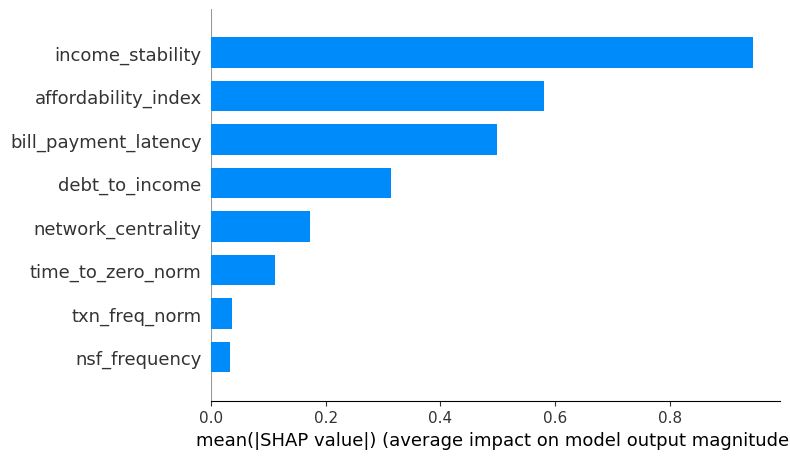

In [ ]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values_test,
    X_test,
    plot_type="bar"
)

/tmp/ipython-input-373/2994091176.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


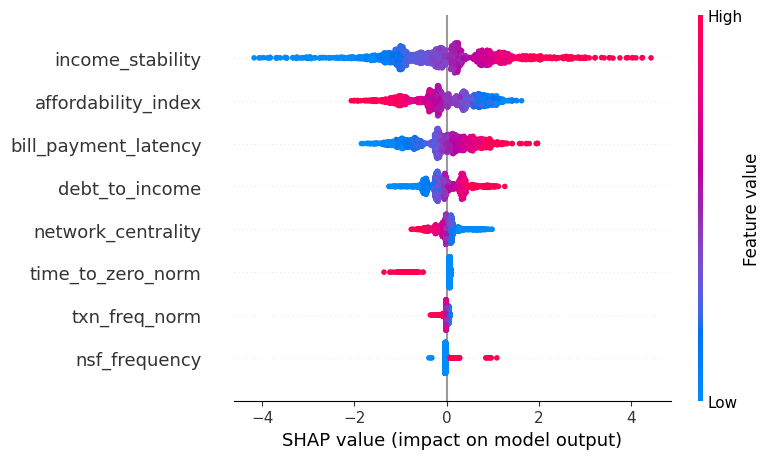

In [ ]:
shap.summary_plot(
    shap_values_test,
    X_test
)

Finalize Reusable Function Properly

In [ ]:
def generate_credit_report(idx):

    applicant = X.loc[idx:idx]

    shap_output = explainer(applicant)
    shap_values = shap_output.values[0]

    pred_prob = model_final.predict_proba(applicant)[:,1][0]
    approval_prob = 1 - pred_prob

    feature_contributions = list(zip(feature_cols, shap_values))

    negative_drivers = [(f,v) for f,v in feature_contributions if v > 0]
    ranked_negative = sorted(
        negative_drivers,
        key=lambda x: abs(x[1]),
        reverse=True
    )

    decision = "REJECTED" if pred_prob >= threshold else "APPROVED"

    print("\n================ CREDIT DECISION REPORT ================\n")
    print(f"Applicant ID: {idx}")
    print(f"Approval Probability: {round(approval_prob,2)}")
    print(f"Decision: {decision}")
    print(f"Threshold: {threshold}\n")

    if decision == "REJECTED":

        print("Top Risk Drivers:\n")

        for i, (feat, val) in enumerate(ranked_negative[:3], 1):
            print(f"{i}. {mapping[feat]} "
                  f"(Impact Strength: {round(abs(val),3)})")

        print("\nSuggested Actions:\n")

        for feat, _ in ranked_negative[:3]:

            if feat == 'income_stability':
                suggestion = "Maintain consistent monthly inflows for 3–6 months."
            elif feat == 'bill_payment_latency':
                suggestion = "Pay all bills before due date consistently."
            elif feat == 'network_centrality':
                suggestion = "Increase verified merchant transactions."
            elif feat == 'affordability_index':
                suggestion = "Improve disposable income ratio."
            elif feat == 'nsf_frequency':
                suggestion = "Avoid low balance alerts."
            elif feat == 'debt_to_income':
                suggestion = "Reduce EMI burden."
            else:
                suggestion = "Improve this financial metric."

            print("-", suggestion)

    else:
        print("Application Approved. Strong financial indicators observed.")

    print("\n========================================================\n")

In [ ]:
generate_credit_report(idx)


================ CREDIT DECISION REPORT ================

Applicant ID: 5962
Approval Probability: 0.16
Decision: REJECTED
Threshold: 0.5

Top Risk Drivers:

1. Your monthly income appears irregular and volatile. (Impact Strength: 1.826)
2. You tend to delay bill payments beyond due dates. (Impact Strength: 0.809)
3. Your financial activity shows limited ecosystem engagement. (Impact Strength: 0.136)

Suggested Actions:

- Maintain consistent monthly inflows for 3–6 months.
- Pay all bills before due date consistently.
- Increase verified merchant transactions.




DiCE

In [ ]:
!pip install dice-ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.3 MB/s eta 0:00:00


In [ ]:
import dice_ml

In [ ]:
train_df = X_dev.copy()
train_df['default'] = y_dev

In [ ]:
d = dice_ml.Data(
    dataframe=train_df,
    continuous_features=feature_cols,
    outcome_name='default'
)

m = dice_ml.Model(
    model=model_final,
    backend='sklearn'
)

exp = dice_ml.Dice(d, m)

In [ ]:
# Select one rejected applicant
idx = 10

query_instance = borrowers_df.iloc[[idx]][feature_cols]

In [ ]:
counterfactuals = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=[
        'income_stability',
        'bill_payment_latency',
        'affordability_index',
        'nsf_frequency',
        'time_to_zero_norm'
    ],
    permitted_range={
        'income_stability': [0.0, 1.0],
        'bill_payment_latency': [-10, 5],
        'affordability_index': [0.0, 1.0],
        'nsf_frequency': [0, 5],
        'time_to_zero_norm': [0.0, 1.0]
    }
)

100%|██████████| 1/1 [00:00<00:00,  1.32it/s]


In [ ]:
cf_df = counterfactuals.cf_examples_list[0].final_cfs_df

print("\n================ PATHS TO APPROVAL ================\n")

for i, row in cf_df.iterrows():

    new_prob = 1 - model_final.predict_proba([row[feature_cols]])[:,1][0]

    print(f"Path {i+1}:")

    for col in feature_cols:
        if row[col] != applicant.iloc[0][col]:
            print(f"  - Change {col} to {round(row[col],3)}")

    print(f"  -> New Approval Probability: {round(new_prob,2)}")
    print("  -> APPROVED\n")


================ PATHS TO APPROVAL ================

Path 1:
  - Change income_stability to 1.1
  - Change affordability_index to 0.712
  - Change bill_payment_latency to -1.5
  - Change network_centrality to 0.06
  - Change debt_to_income to 0.008
  - Change txn_freq_norm to 0.03
  -> New Approval Probability: 0.4
  -> APPROVED

Path 2:
  - Change income_stability to 0.9
  - Change affordability_index to 0.712
  - Change bill_payment_latency to 4.0
  - Change network_centrality to 0.06
  - Change debt_to_income to 0.008
  - Change txn_freq_norm to 0.03
  -> New Approval Probability: 0.41
  -> APPROVED

Path 3:
  - Change income_stability to 0.9
  - Change affordability_index to 0.712
  - Change bill_payment_latency to 3.2
  - Change network_centrality to 0.06
  - Change debt_to_income to 0.008
  - Change txn_freq_norm to 0.03
  -> New Approval Probability: 0.44
  -> APPROVED



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("\n================ PATHS TO APPROVAL ================\n")

for i, row in cf_df.iterrows():

    default_prob = model_final.predict_proba([row[feature_cols]])[:,1][0]
    approval_prob = 1 - default_prob

    print(f"Path {i+1}:\n")

    changes = []

    for col in feature_cols:
        original_val = applicant.iloc[0][col]
        new_val = row[col]

        if abs(original_val - new_val) > 1e-3:

            if col == 'income_stability':
                changes.append("Improve income consistency over next 3–6 months.")

            elif col == 'bill_payment_latency':
                changes.append("Pay bills before due date consistently.")

            elif col == 'nsf_frequency':
                changes.append("Maintain higher minimum balance to reduce low balance alerts.")

            elif col == 'affordability_index':
                changes.append("Increase disposable income or reduce current expenses.")

            elif col == 'time_to_zero_norm':
                changes.append("Maintain a stronger balance buffer after income credit.")

            else:
                changes.append(f"Improve {col}.")

    for action in changes:
        print(f"- {action}")

    print(f"\n-> New Approval Probability: {round(approval_prob,2)}")
    print("-> APPROVED\n")


================ PATHS TO APPROVAL ================

Path 1:

- Improve income consistency over next 3–6 months.
- Increase disposable income or reduce current expenses.
- Pay bills before due date consistently.
- Improve network_centrality.
- Improve debt_to_income.
- Improve txn_freq_norm.

-> New Approval Probability: 0.4
-> APPROVED

Path 2:

- Improve income consistency over next 3–6 months.
- Increase disposable income or reduce current expenses.
- Pay bills before due date consistently.
- Improve network_centrality.
- Improve debt_to_income.
- Improve txn_freq_norm.

-> New Approval Probability: 0.41
-> APPROVED

Path 3:

- Improve income consistency over next 3–6 months.
- Increase disposable income or reduce current expenses.
- Pay bills before due date consistently.
- Improve network_centrality.
- Improve debt_to_income.
- Improve txn_freq_norm.

-> New Approval Probability: 0.44
-> APPROVED



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


FINAL UNIFIED FUNCTION

In [ ]:
def generate_credit_report(idx):

    applicant = X.loc[idx:idx]

    shap_output = explainer(applicant)
    shap_values = shap_output.values[0]

    pred_prob = model_final.predict_proba(applicant)[:,1][0]
    approval_prob = 1 - pred_prob

    decision = "APPROVED" if approval_prob >= threshold else "REJECTED"

    feature_contributions = list(zip(feature_cols, shap_values))

    negative_drivers = [(f,v) for f,v in feature_contributions if v > 0]
    ranked_negative = sorted(
        negative_drivers,
        key=lambda x: abs(x[1]),
        reverse=True
    )

    print("\n====================================================")
    print("              CREDIT DECISION REPORT")
    print("====================================================\n")

    print(f"Applicant ID: {idx}")
    print(f"Approval Probability: {round(approval_prob,2)}")
    print(f"Threshold: {threshold}")
    print(f"Final Decision: {decision}\n")

    # -------------------------------------------------
    # SHAP Explanation Section
    # -------------------------------------------------

    if decision == "REJECTED":

        print("Why Your Application Was Not Approved:\n")

        for i, (feat, val) in enumerate(ranked_negative[:3], 1):
            print(f"{i}. {mapping[feat]} "
                  f"(Impact Strength: {round(abs(val),3)})")

        print("\nThese factors increased your estimated default risk "
              "above the approval threshold.\n")

        # -------------------------------------------------
        # DiCE Counterfactual Section
        # -------------------------------------------------

        print("Paths to Approval:\n")

        query_instance = applicant.copy()

        counterfactuals = exp.generate_counterfactuals(
            query_instance,
            total_CFs=3,
            desired_class="opposite"
        )

        cf_df = counterfactuals.cf_examples_list[0].final_cfs_df

        for i, row in cf_df.iterrows():

            default_prob = model_final.predict_proba([row[feature_cols]])[:,1][0]
            new_approval = 1 - default_prob

            print(f"Path {i+1}:\n")

            for col in feature_cols:
                original_val = applicant.iloc[0][col]
                new_val = row[col]

                if abs(original_val - new_val) > 1e-3:

                    if col == 'income_stability':
                        print("- Improve income consistency over next 3–6 months.")

                    elif col == 'bill_payment_latency':
                        print("- Pay bills before due date consistently.")

                    elif col == 'nsf_frequency':
                        print("- Maintain higher minimum balance to reduce low balance alerts.")

                    elif col == 'affordability_index':
                        print("- Increase disposable income ratio.")

                    elif col == 'time_to_zero_norm':
                        print("- Maintain stronger balance buffer after salary credit.")

                    elif col == 'debt_to_income':
                        print("- Reduce existing EMI burden.")

                    else:
                        print(f"- Improve {col}.")

            print(f"\n-> New Approval Probability: {round(new_approval,2)}")
            print("-> APPROVED\n")

    else:
        print("Your application has been approved.")
        print("Your financial behavior indicators are within acceptable risk limits.\n")

    print("====================================================\n")

In [ ]:
generate_credit_report(10)


              CREDIT DECISION REPORT

Applicant ID: 10
Approval Probability: 1.0
Threshold: 0.5
Final Decision: APPROVED

Your application has been approved.
Your financial behavior indicators are within acceptable risk limits.




In [ ]:
def preprocess_transactions(file_path):

    import pandas as pd
    import numpy as np

    transactions_df = pd.read_csv(file_path)
    transactions_df['timestamp'] = pd.to_datetime(transactions_df['timestamp'])
    transactions_df['year_month'] = transactions_df['timestamp'].dt.to_period('M')

    # Monthly income aggregation
    monthly_income = (
        transactions_df.groupby(['sender_upi_id','year_month'])['amount']
        .sum()
        .reset_index()
    )

    income_stats = (
        monthly_income.groupby('sender_upi_id')['amount']
        .agg(['mean','std'])
        .reset_index()
    )

    income_stats['income_stability'] = income_stats['std'] / income_stats['mean']
    income_stats['income_stability'].fillna(0, inplace=True)

    # Transaction frequency
    txn_freq = (
        transactions_df.groupby('sender_upi_id')
        .size()
        .reset_index(name='txn_count')
    )
    txn_freq['txn_freq_norm'] = txn_freq['txn_count'] / 100

    # Merchant diversity
    merchant_div = (
        transactions_df.groupby('sender_upi_id')['receiver_upi_id']
        .nunique()
        .reset_index(name='merchant_count')
    )
    merchant_div['network_centrality'] = merchant_div['merchant_count'] / 50

    # NSF frequency
    nsf_df = transactions_df[transactions_df['transfer_ratio'] > 0.9]
    nsf_freq = (
        nsf_df.groupby('sender_upi_id')
        .size()
        .reset_index(name='nsf_frequency')
    )

    # Time-to-zero proxy
    ttz_df = transactions_df[transactions_df['transfer_ratio'] > 0.8]
    ttz = (
        ttz_df.groupby('sender_upi_id')
        .size()
        .reset_index(name='near_zero_events')
    )
    ttz['time_to_zero_norm'] = 1 / (1 + ttz['near_zero_events'])

    borrowers_df = income_stats[['sender_upi_id','income_stability']]

    borrowers_df = borrowers_df.merge(
        txn_freq[['sender_upi_id','txn_freq_norm']], on='sender_upi_id', how='left'
    )
    borrowers_df = borrowers_df.merge(
        merchant_div[['sender_upi_id','network_centrality']], on='sender_upi_id', how='left'
    )
    borrowers_df = borrowers_df.merge(
        nsf_freq, on='sender_upi_id', how='left'
    )
    borrowers_df = borrowers_df.merge(
        ttz[['sender_upi_id','time_to_zero_norm']], on='sender_upi_id', how='left'
    )

    borrowers_df.fillna(0, inplace=True)

    # Synthetic financial proxies (since raw Excel doesn't have them)
    borrowers_df['debt_to_income'] = np.random.uniform(0, 0.4, len(borrowers_df))
    borrowers_df['affordability_index'] = 1 - borrowers_df['debt_to_income']
    borrowers_df['bill_payment_latency'] = np.random.normal(3, 5, len(borrowers_df))

    return borrowers_df

In [ ]:
def api_predict(file_path):

    borrowers_df = preprocess_transactions(file_path)

    features = borrowers_df[feature_cols]

    probs = model_final.predict_proba(features)[:,1]

    borrowers_df['default_probability'] = probs
    borrowers_df['approval_probability'] = 1 - probs

    return borrowers_df[['sender_upi_id','approval_probability']]

In [ ]:
api_predict("synthetic_upi_transactions.csv").head()

/tmp/ipython-input-373/1345936110.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  income_stats['income_stability'].fillna(0, inplace=True)


,sender_upi_id,approval_probability
0,aaronbautista@oksbi,0.815440
1,aaronbolton@oksbi,0.215403
2,aaronbrown@ybl,0.987146
3,aaronburton@okaxis,0.908861
4,aaroncarrillo@ybl,0.984125
